In [1]:
# -*- coding: utf-8 -*-
#  Copyright 2024 United Kingdom Research and Innovation
#
#  Licensed under the Apache License, Version 2.0 (the "License");
#  you may not use this file except in compliance with the License.
#  You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
#  Unless required by applicable law or agreed to in writing, software
#  distributed under the License is distributed on an "AS IS" BASIS,
#  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#  See the License for the specific language governing permissions and
#  limitations under the License.
#
#  Authored by:    Rasmia Kulan (UKRI-STFC)
#                  Laura Murgatroyd (UKRI-STFC)

# Introduction to Aluminium Cylinder

This exercise guides you through the steps needed to load, preprocess, and reconstruct a set of 2D slices from a 3D dataset of an aluminum cylinder sample containing regions with multiple materials, using Filtered Back Projection (FBP). Learning objectives are:
- Load and investigate data sets of the Aluminium Cylinder at different acquisitions (3.75 a, 3.75 b, 7.5, 15 and 30 seconds). 
- Add these acquisitions to form a 1minute acquisition and slice through different regions of interest.
- Apply CIL processors to pre-process the data including Mask Generator, Normalisation, Row Corrected Normalisation, Transmission Absorption Conversion and Centre of Rotation Correction.


In [2]:
from cil.utilities.display import show2D
import numpy as np
import matplotlib.pyplot as plt
from data_io.read_and_write import read_processed_data
from cil.io import TIFFStackReader


There is an upper and lower cylinder in this sample. The lower cylinder has holes with 1mm, 2mm, 3mm and 4mm diameters, and they are filled with: 
- ZrO2 spheres(0.5mm dia), 
- Trisospheres(1mm dia), 
- Mixture of ZrO2 and trisopheres,
- Steel spheres (2mm dia) in Al foil respectively, as shown in the attached rough figure.

Both the bases are Al and the rods in the upper cylinder...we weren't sure what they were made of but measuring with a portable element analyzer indicates that the rods (all 2mm dia) are made of ~90%Si alloyed with small amounts of Fe/Al.

We have already pre-processed the data using Mantid Imaging
Can be installed here along with file showing preprocessing steps TODO

Update data_io/file_paths.py 'xxx' variable to point to path to preprocessed data

In this notebook we will just look at the 60 second data (ie the largest exposure time we have).
To load in the preprocessed data:

In [3]:
data = read_processed_data(exposure_time=60, num_angles=840)

Here we show a single projection of the 60 second acquistion.

Number of dimensions: 3
Shape: (840, 1550, 620)
Axis labels: (<AcquisitionDimension.ANGLE: 'angle'>, <AcquisitionDimension.VERTICAL: 'vertical'>, <AcquisitionDimension.HORIZONTAL: 'horizontal'>)



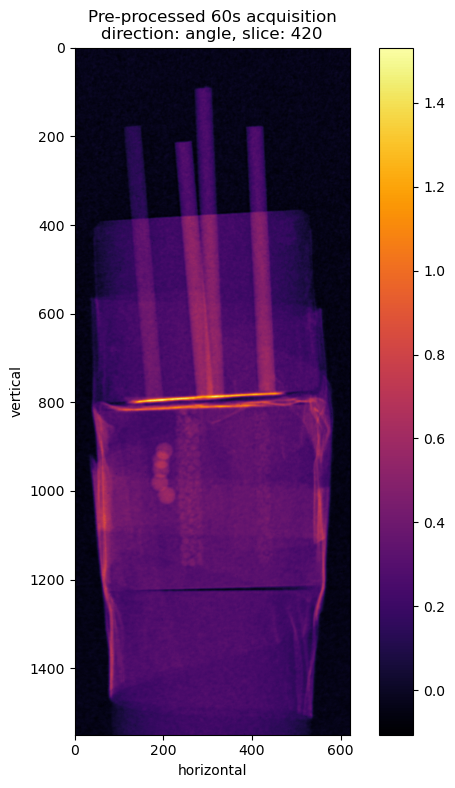

In [4]:
print(data)
show2D(data, title='Pre-processed 60s acquisition', cmap='inferno', origin='upper')

We have chosen three different Region of Interests from the cylinder as shown below:

<img src="images/cylinder_slices.png" width=800 align="center">

In [5]:
#Use CIL to slice the pre-processed data at these locations
from cil.processors import Slicer
exp_1min_slice1 = Slicer(roi={'vertical': (245, 246)})(data)
exp_1min_slice2 = Slicer(roi={'vertical': (623, 624)})(data)
exp_1min_slice3 = Slicer(roi={'vertical': (987, 988)})(data)



Unable to calculate the requested 2D geometry. Returning geometry=`None`
Unable to calculate the requested 2D geometry. Returning geometry=`None`
Unable to calculate the requested 2D geometry. Returning geometry=`None`


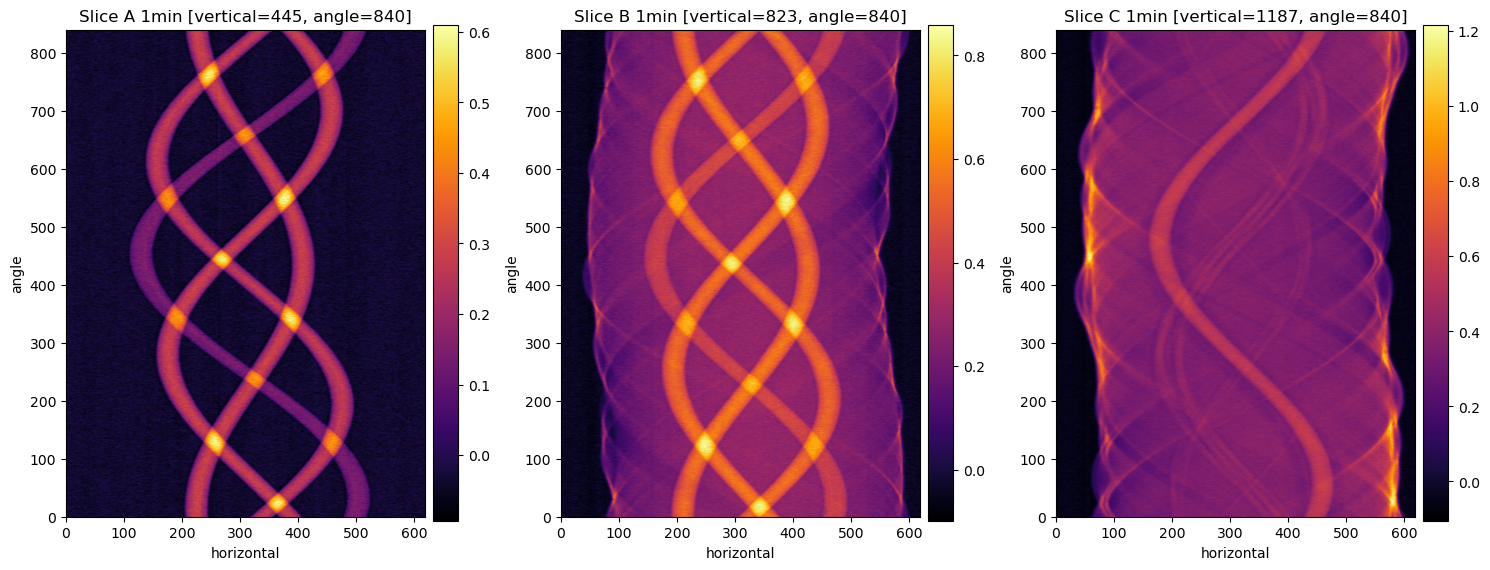

In [6]:

show2D([exp_1min_slice1, exp_1min_slice2, exp_1min_slice3],['Slice A 1min [vertical=445, angle=840]', 'Slice B 1min [vertical=823, angle=840]', 'Slice C 1min [vertical=1187, angle=840]'], num_cols=3, cmap='inferno')

The three regions are chosen based on various parts of the sample:
- Slice A is cut through where there is just rods and air (no cylinder background)
- Slice B is a cut through where there are rods in the holes through the cylinder
- Slice C is a cut through the region where there are spheres in the holes through the cylinder

In [7]:
from cil.recon import FBP

exp_1min_rec1 = FBP(exp_1min_slice1).run()
exp_1min_rec2 = FBP(exp_1min_slice2).run()
exp_1min_rec3 = FBP(exp_1min_slice3).run()


all_exp = [
    exp_1min_rec1, exp_1min_rec2, exp_1min_rec3
]

all_labels = [
'Slice A FBP [vertical=445, angle=840]','Slice B FBP [vertical=823, angle=840]', 'Slice C FBP [vertical=1187, angle=840]'
]

show2D(all_exp,all_labels, cmap='inferno', num_cols=3 ,fix_range=(-0.002, 0.010))


TypeError: Input type mismatch: got <class 'cil.framework.data_container.DataContainer'> expecting <class 'cil.framework.acquisition_data.AcquisitionData'>

We have plotted Pixel Values against the Number of Pixels to examine the number of peaks against the number of materials used in the sample

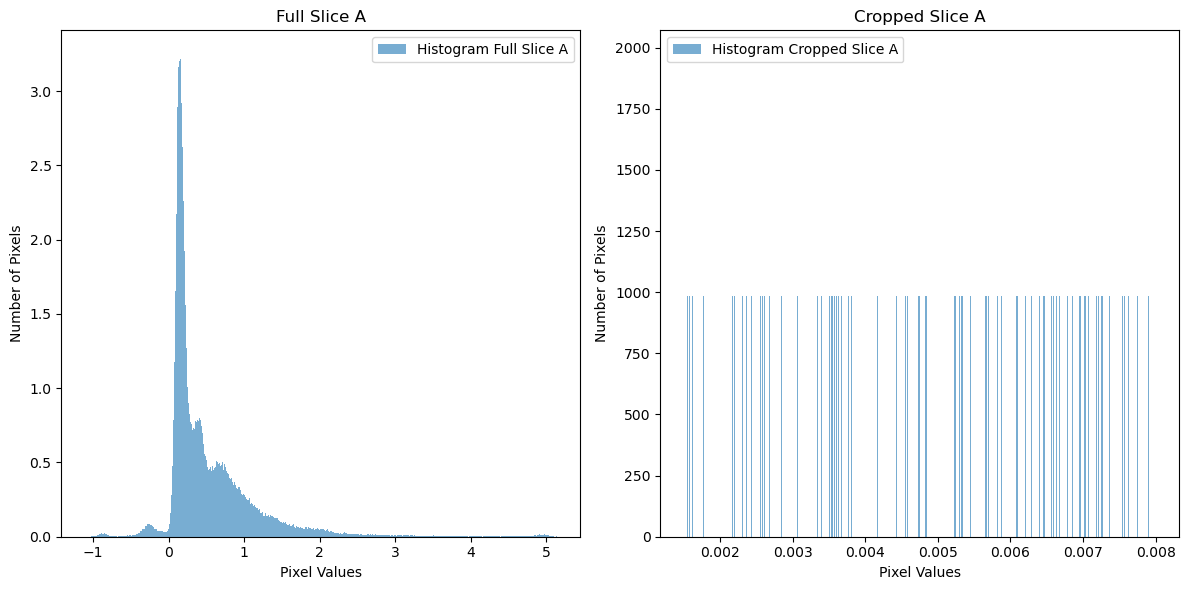

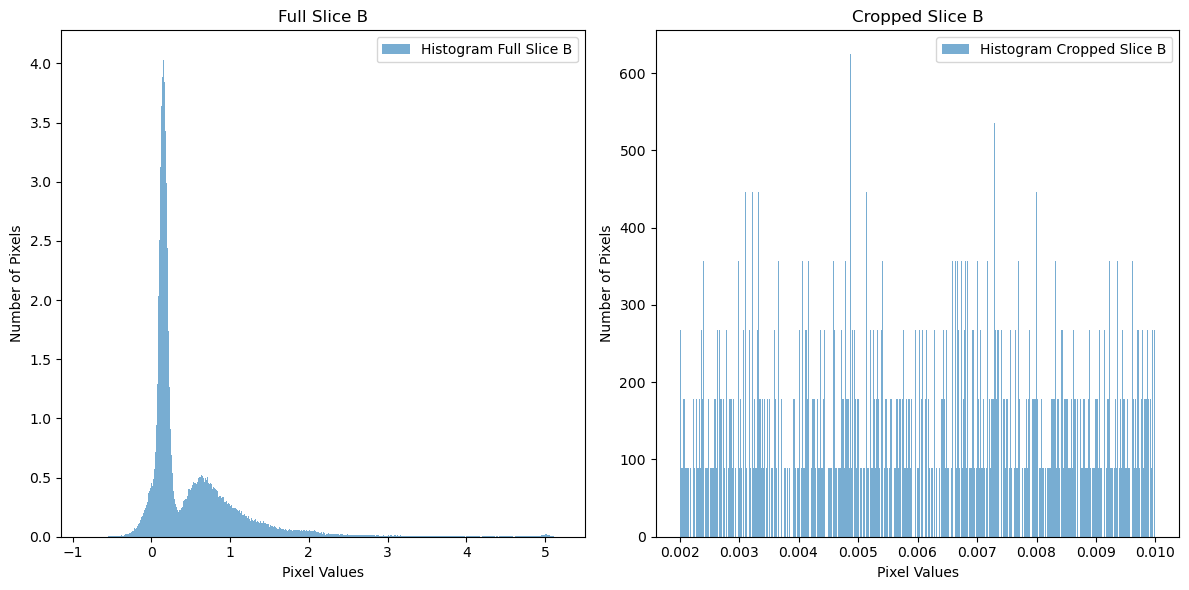

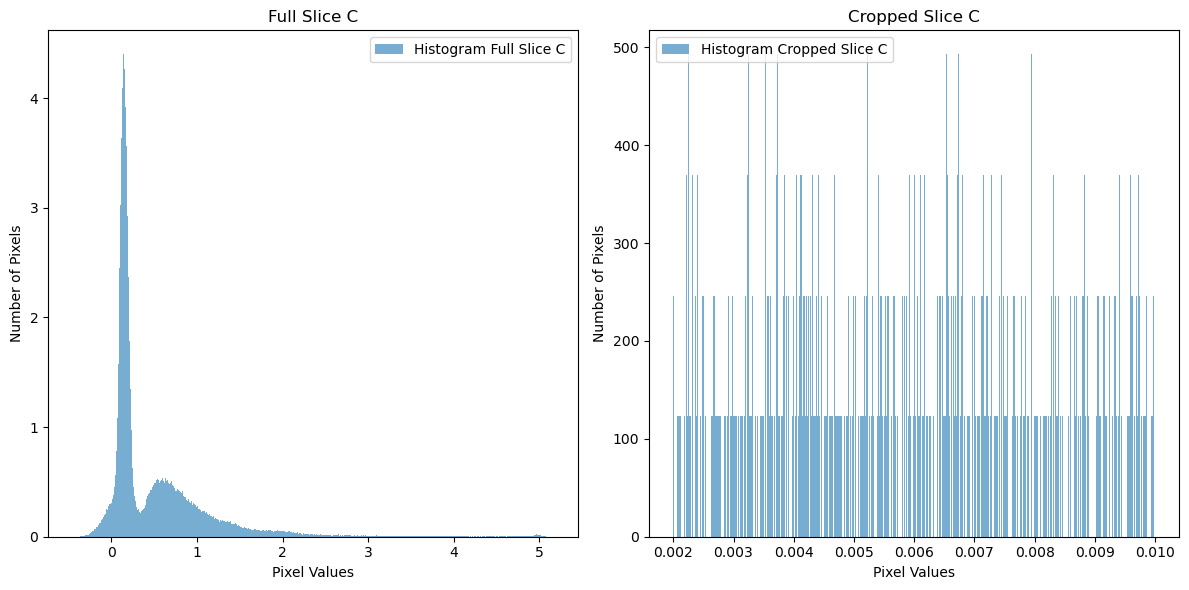

In [ ]:
def show_hist_for_recons(dataset,start, stop, label1, label2):
    # Convert dataset to 2D array
    data_2d = dataset.as_array()

    # Flatten the 2D array to 1D
    data = data_2d.flatten()

    # Check if data is empty or contains NaNs
    if len(data) == 0:
        print(f"Data set is invalid.")
        return
    
    # Create a new figure with subplots
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    
    # Plot first histogram without range constraint
    axs[0].hist(data, bins=1000, density=True, alpha=0.6, label=f'Histogram {label1}')
    axs[0].set_xlabel('Pixel Values')
    axs[0].set_ylabel('Number of Pixels')
    axs[0].set_title(f'{label1}')
    axs[0].legend()
    
    # Plot histogram with range of interest
    axs[1].hist(data, bins=1000, density=True, alpha=0.6, range=(start, stop), label=f'Histogram {label2}')
    axs[1].set_xlabel('Pixel Values')
    axs[1].set_ylabel('Number of Pixels')
    axs[1].set_title(f'{label2}')
    axs[1].legend()

    # Adjust layout
    plt.tight_layout()
    
    # Display the histograms
    plt.show()


show_hist_for_recons(exp_1min_rec1,0.0015, 0.008, 'Full Slice A', 'Cropped Slice A')
show_hist_for_recons(exp_1min_rec2,0.002,0.010,'Full Slice B','Cropped Slice B')
show_hist_for_recons(exp_1min_rec3,0.002,0.010,'Full Slice C', 'Cropped Slice C')


Concluding the results above:
- Slice A - Full slice shows a peak at 0.00 pixel value as it does not have a cylinder background along with peaks at ~0.0045 and ~0.0075 in the Cropped version indicating the contrast of the two types of rods.
- Slice B - Compared to slice A, the peak at ~0.00 is more spread out because the slice background and the cylinder background merge. Cropping out the non-cylinder background displays peaks at ~0.002 indicating the cylinder background, ~0.0045 and ~0.0075 indicating the contrast of the two types of rods.
- Slice C - Cropping out the non-cylinder background displays less defined peaks because the ROI within the cylinder are very small aswell as the foil around the cylinder has a broader range of pixel values.